In [38]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('skin_irritation_2Ddesc.csv')

# y(label)와 X(descriptor) 분리
y = df['label']
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])

# NaN 열 제거
X = X.dropna(axis=1)
# 표준편차 0.01 미만 (거의 같은 값) 열 제거
X = X.loc[:, X.std() >= 0.01]

print('X shape:', X.shape)
print('y 분포:')
print(y.value_counts())

X shape: (39, 144)
y 분포:
label
0    26
1    13
Name: count, dtype: int64


In [39]:
from sklearn.feature_selection import SelectKBest, f_classif

# 상위 10개 descriptor 선택
selector = SelectKBest(f_classif, k=10)
selector.fit(X, y)
cols = X.columns[selector.get_support()]
X_sel = X[cols]

print('선택된 descriptor:')
print(list(cols))

선택된 descriptor:
['MinAbsEStateIndex', 'BertzCT', 'Chi0', 'Chi1', 'PEOE_VSA7', 'SlogP_VSA6', 'HeavyAtomCount', 'MolMR', 'fr_C_O_noCOO', 'fr_ester']


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 단일 결정 트리 학습 (random_state=0: 결과 고정용)
dt = DecisionTreeClassifier(max_depth=3, random_state=0)
dt.fit(X_sel, y)

print('train:', round(dt.score(X_sel, y), 3))
print('CV5  :', round(cross_val_score(dt, X_sel, y, cv=5).mean(), 3))

train: 0.949
CV5  : 0.639


In [41]:
# 결정 트리 grid search (worked example)
max_depths = [2, 3, 5, None]      # None = 제한 없음
min_splits = [2, 4, 6]

for d in max_depths:
    for s in min_splits:
        # 모델 생성
        dt = DecisionTreeClassifier(max_depth=d, min_samples_split=s, random_state=0)
        # 학습 + 학습 정확도
        train = dt.fit(X_sel, y).score(X_sel, y)
        # 5-fold 교차검증 정확도
        cv = cross_val_score(dt, X_sel, y, cv=5).mean()
        print(f'depth={d}, split={s} | train={train:.3f} | CV5={cv:.3f}')

depth=2, split=2 | train=0.846 | CV5=0.721
depth=2, split=4 | train=0.846 | CV5=0.721
depth=2, split=6 | train=0.846 | CV5=0.721
depth=3, split=2 | train=0.949 | CV5=0.639
depth=3, split=4 | train=0.923 | CV5=0.639
depth=3, split=6 | train=0.923 | CV5=0.639
depth=5, split=2 | train=1.000 | CV5=0.643
depth=5, split=4 | train=0.974 | CV5=0.643
depth=5, split=6 | train=0.974 | CV5=0.668
depth=None, split=2 | train=1.000 | CV5=0.668
depth=None, split=4 | train=0.974 | CV5=0.668
depth=None, split=6 | train=0.974 | CV5=0.693


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

n_estimators = [50, 100, 200]
max_depths = [3, 5, 7, None]

# ✏️ Quiz: Random Forest grid search
# 힌트: B-1 결정 트리 grid search 코드(partb-code-002)와 동일한 패턴
#       모델만 RandomForestClassifier(n_estimators=n, max_depth=d, random_state=0)
for n in n_estimators:
    for d in max_depths:
        # RandomForestClassifier 생성
        
        # 학습 + train 점수
        
        # 5-fold CV 점수
        
        # 결과 출력 (예: 'n=100, depth=5 | train=0.949 | CV5=0.821')
        pass

In [43]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

n_estimators = [50, 100, 200]
max_depths = [3, 5, 7]
learning_rates = [0.05, 0.1, 0.3]

# ✏️ Quiz: XGBoost grid search
# 힌트: 3중 for문 (n_estimators × max_depth × learning_rate)
#       XGBClassifier(n_estimators=n, max_depth=d, learning_rate=lr,
#                     random_state=0, eval_metric='logloss')
for n in n_estimators:
    for d in max_depths:
        for lr in learning_rates:
            # XGBClassifier 생성
            
            # 학습 + train 점수
            
            # 5-fold CV 점수
            
            # 결과 출력 (예: 'n=100, depth=3, lr=0.1 | train=1.000 | CV5=0.793')
            pass

In [44]:
import pandas as pd
import warnings
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

results = []
k_candidates = [4, 6, 8, 10, 12, 14]

# 모델별 hyperparameter (간소화)
dt_grid  = [(d, s) for d in [3, 5, None] for s in [2, 4]]
rf_grid  = [(n, d) for n in [100, 200] for d in [3, 5, None]]
xgb_grid = [(n, d, lr) for n in [100, 200] for d in [3, 5] for lr in [0.05, 0.1]]

for k in k_candidates:
    # k개 descriptor 선택
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X, y)
    cols = X.columns[selector.get_support()]
    X_sel = X[cols]
    
    # ✏️ Decision Tree 결과 추가 (worked example)
    for d, s in dt_grid:
        m = DecisionTreeClassifier(max_depth=d, min_samples_split=s, random_state=0)
        train = m.fit(X_sel, y).score(X_sel, y)
        cv = cross_val_score(m, X_sel, y, cv=5).mean()
        results.append({'model': 'DT', 'k': k, 'param': f'{d, s}',
                        'train': round(train, 3), 'cv': round(cv, 3)})
    
    # ✏️ Quiz: Random Forest 결과 추가
    # 힌트: dt_grid 패턴 그대로, model='RF', param=f'{n, d}'
    for n, d in rf_grid:
        pass
    
    # ✏️ Quiz: XGBoost 결과 추가 (model='XGB', param=f'{n, d, lr}')
    for n, d, lr in xgb_grid:
        pass

results_df = pd.DataFrame(results)
results_df.to_csv('experiment_results_tree.csv', index=False)
print('저장 완료: experiment_results_tree.csv  /  전체 실험:', len(results_df), '개')
results_df.head()

저장 완료: experiment_results_tree.csv  /  전체 실험: 36 개


,model,k,param,train,cv
0,DT,4,"(3, 2)",0.897,0.611
1,DT,4,"(3, 4)",0.897,0.611
2,DT,4,"(5, 2)",1.000,0.689
3,DT,4,"(5, 4)",1.000,0.664
4,DT,4,"(None, 2)",1.000,0.689


In [45]:
# 1번 문제
top5 = results_df.sort_values('cv', ascending=False).head(5)
top5

,model,k,param,train,cv
29,DT,12,"(None, 4)",0.974,0.771
28,DT,12,"(None, 2)",1.000,0.771
17,DT,8,"(None, 4)",0.974,0.771
16,DT,8,"(None, 2)",1.000,0.771
27,DT,12,"(5, 4)",0.974,0.746


In [46]:
# 2번 문제

best_by_model = results_df.sort_values('cv', ascending=False).groupby('model').head(1)
best_by_model

,model,k,param,train,cv
29,DT,12,"(None, 4)",0.974,0.771


In [47]:
# 3번 문제

best_by_model.to_csv('experiment_best_tree.csv', index=False)
print('저장 완료: experiment_best_tree.csv')

저장 완료: experiment_best_tree.csv


In [48]:
import matplotlib.pyplot as plt
import numpy as np

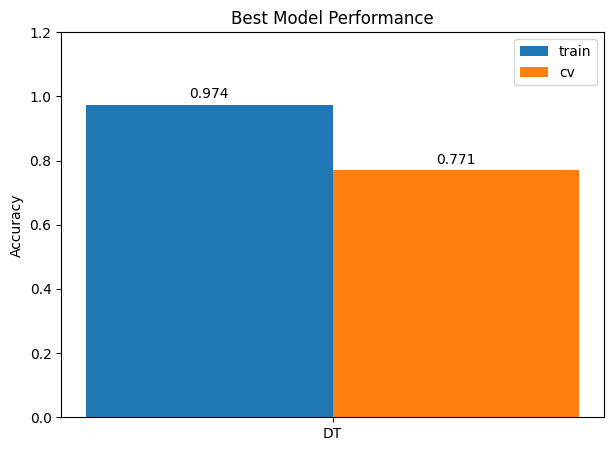

In [49]:
import matplotlib.pyplot as plt
import numpy as np

best_each = results_df.sort_values('cv', ascending=False).groupby('model').head(1)
best_each = best_each.sort_values('model')

x = np.arange(len(best_each))
width = 0.35

plt.figure(figsize=(7, 5))

plt.bar(x - width/2, best_each['train'], width, label='train')
plt.bar(x + width/2, best_each['cv'], width, label='cv')

plt.xticks(x, best_each['model'])
plt.ylim(0, 1.2)
plt.ylabel('Accuracy')
plt.title('Best Model Performance')

plt.legend()

for i, v in enumerate(best_each['train']):
    plt.text(x[i] - width/2, v + 0.02, f'{v:.3f}', ha='center')

for i, v in enumerate(best_each['cv']):
    plt.text(x[i] + width/2, v + 0.02, f'{v:.3f}', ha='center')

plt.show()

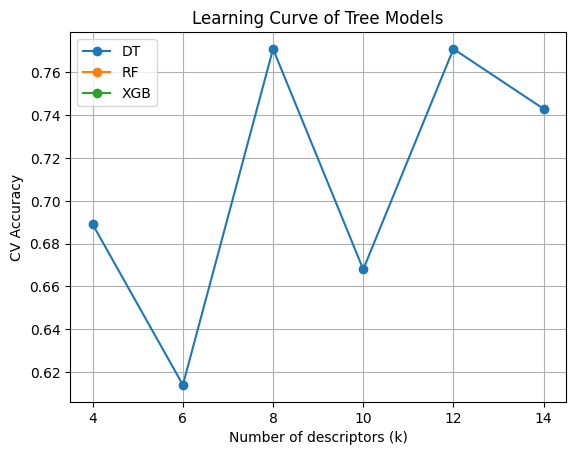

In [50]:
import matplotlib.pyplot as plt

for model in ['DT', 'RF', 'XGB']:
    
    df_m = results_df[results_df['model'] == model]
    
    df_m_best = (
        df_m.sort_values('cv', ascending=False)
        .groupby('k')
        .head(1)
        .sort_values('k')
    )
    
    plt.plot(
        df_m_best['k'],
        df_m_best['cv'],
        marker='o',
        label=model
    )

plt.xlabel('Number of descriptors (k)')
plt.ylabel('CV Accuracy')
plt.title('Learning Curve of Tree Models')

plt.legend()
plt.grid()

plt.show()

In [51]:
# 모든 실험 결과 저장
results_df.to_csv('experiment_results_tree.csv', index=False)

# 모델별 최고 결과 저장
best_each = (
    results_df.sort_values('cv', ascending=False)
    .groupby('model')
    .head(1)
)

best_each.to_csv('experiment_best_tree.csv', index=False)

print('저장 완료!')
print('- experiment_results_tree.csv')
print('- experiment_best_tree.csv')

저장 완료!
- experiment_results_tree.csv
- experiment_best_tree.csv


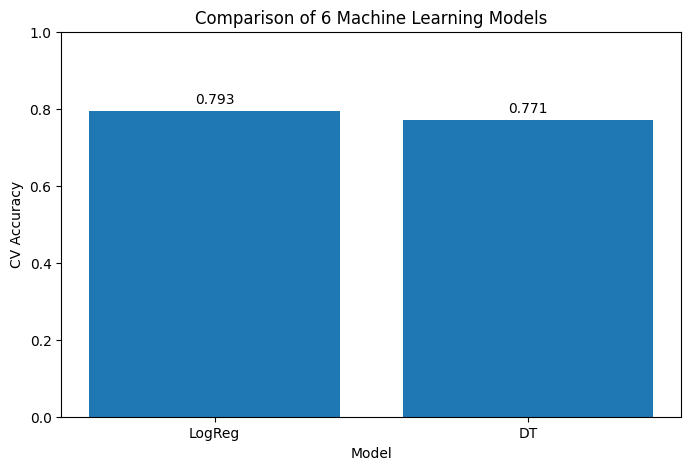

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# 지난 시간 결과
df_old = pd.read_csv('experiment_results.csv')

# 이번 시간 결과
df_tree = pd.read_csv('experiment_best_tree.csv')

# 지난 시간 모델별 최고 결과
best_old = (
    df_old.sort_values('cv', ascending=False)
    .groupby('model')
    .head(1)
)

# 필요한 열만 선택
best_old = best_old[['model', 'cv']]
best_tree = df_tree[['model', 'cv']]

# 합치기
final_df = pd.concat([best_old, best_tree])

# 그래프
plt.figure(figsize=(8, 5))

plt.bar(final_df['model'], final_df['cv'])

plt.ylim(0, 1.0)

plt.xlabel('Model')
plt.ylabel('CV Accuracy')
plt.title('Comparison of 6 Machine Learning Models')

# 막대 위 점수 표시
for i, v in enumerate(final_df['cv']):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.show()

In [53]:
import pandas as pd

df_old = pd.read_csv('experiment_results.csv')
df_tree = pd.read_csv('experiment_best_tree.csv')

print(df_old['model'].unique())
print(df_tree['model'].unique())

<StringArray>
['LogReg']
Length: 1, dtype: str
<StringArray>
['DT']
Length: 1, dtype: str


In [54]:
print(results_df['model'].unique())

<StringArray>
['DT']
Length: 1, dtype: str


In [55]:
results = []

for k in k_candidates:
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X, y)
    cols = X.columns[selector.get_support()]
    X_sel = X[cols]

    for d, s in dt_grid:
        m = DecisionTreeClassifier(max_depth=d, min_samples_split=s, random_state=0)
        train = m.fit(X_sel, y).score(X_sel, y)
        cv = cross_val_score(m, X_sel, y, cv=5).mean()
        results.append({'model': 'DT', 'k': k, 'param': f'{d, s}',
                        'train': round(train, 3), 'cv': round(cv, 3)})

    for n, d in rf_grid:
        m = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=0)
        train = m.fit(X_sel, y).score(X_sel, y)
        cv = cross_val_score(m, X_sel, y, cv=5).mean()
        results.append({'model': 'RF', 'k': k, 'param': f'{n, d}',
                        'train': round(train, 3), 'cv': round(cv, 3)})

    for n, d, lr in xgb_grid:
        m = XGBClassifier(n_estimators=n, max_depth=d, learning_rate=lr,
                          random_state=0, eval_metric='logloss')
        train = m.fit(X_sel, y).score(X_sel, y)
        cv = cross_val_score(m, X_sel, y, cv=5).mean()
        results.append({'model': 'XGB', 'k': k, 'param': f'{n, d, lr}',
                        'train': round(train, 3), 'cv': round(cv, 3)})

results_df = pd.DataFrame(results)

print(results_df['model'].unique())
results_df.head()

<StringArray>
['DT', 'RF', 'XGB']
Length: 3, dtype: str


,model,k,param,train,cv
0,DT,4,"(3, 2)",0.897,0.611
1,DT,4,"(3, 4)",0.897,0.611
2,DT,4,"(5, 2)",1.000,0.689
3,DT,4,"(5, 4)",1.000,0.664
4,DT,4,"(None, 2)",1.000,0.689


In [56]:
results_df.to_csv('experiment_results_tree.csv', index=False)

best_each = (
    results_df.sort_values('cv', ascending=False)
    .groupby('model')
    .head(1)
)

best_each.to_csv('experiment_best_tree.csv', index=False)

print(best_each)

   model   k          param  train     cv
67    RF  10       (100, 5)  1.000  0.796
45    DT   8      (None, 4)  0.974  0.771
73   XGB  10  (100, 3, 0.1)  0.974  0.768


In [59]:
df_old = pd.read_csv('experiment_results.csv')
print(df_old['model'].unique())

<StringArray>
['LogReg']
Length: 1, dtype: str


In [60]:
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import pandas as pd

df_old = pd.read_csv('experiment_results.csv')
results = df_old.to_dict('records')

for k in [5, 10, 15, 20, 25, 30]:
    X_k = X.iloc[:, :k]

    for h in [5, 10, 20, 50, 100]:
        m = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(h,), max_iter=1000, random_state=0))
        train = m.fit(X_k, y).score(X_k, y)
        cv = cross_val_score(m, X_k, y, cv=5).mean()
        results.append({'model':'MLP', 'k':k, 'param':h, 'train':round(train,3), 'cv':round(cv,3)})

    for c in [0.01, 0.1, 1, 10, 100]:
        m = make_pipeline(StandardScaler(), SVC(C=c))
        train = m.fit(X_k, y).score(X_k, y)
        cv = cross_val_score(m, X_k, y, cv=5).mean()
        results.append({'model':'SVM', 'k':k, 'param':c, 'train':round(train,3), 'cv':round(cv,3)})

results_df_old = pd.DataFrame(results)
results_df_old.to_csv('experiment_results.csv', index=False)

print(results_df_old['model'].unique())

<StringArray>
['LogReg', 'MLP', 'SVM']
Length: 3, dtype: str


     model     cv
1   LogReg  0.793
19     MLP  0.818
67     SVM  0.768
1       DT  0.771
0       RF  0.796
2      XGB  0.768


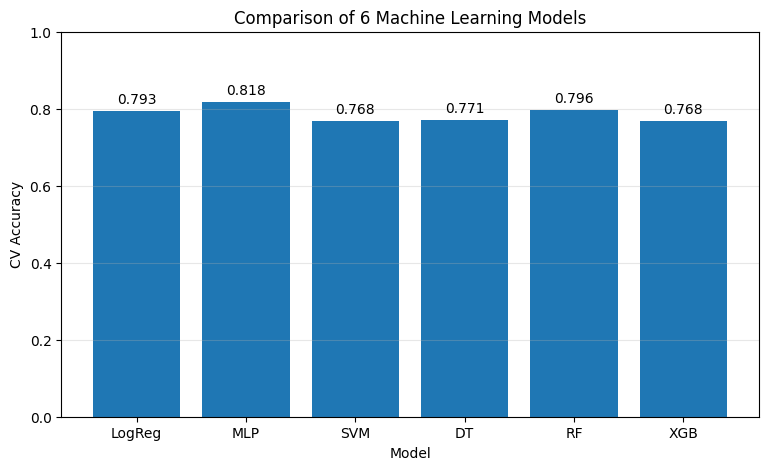

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

df_old = pd.read_csv('experiment_results.csv')
df_tree = pd.read_csv('experiment_best_tree.csv')

best_old = df_old.sort_values('cv', ascending=False).groupby('model').head(1)

final_df = pd.concat([
    best_old[['model', 'cv']],
    df_tree[['model', 'cv']]
])

order = ['LogReg', 'MLP', 'SVM', 'DT', 'RF', 'XGB']
final_df['model'] = pd.Categorical(final_df['model'], categories=order, ordered=True)
final_df = final_df.sort_values('model')

print(final_df)

plt.figure(figsize=(9, 5))
plt.bar(final_df['model'].astype(str), final_df['cv'])

plt.ylim(0, 1.0)
plt.xlabel('Model')
plt.ylabel('CV Accuracy')
plt.title('Comparison of 6 Machine Learning Models')

for i, v in enumerate(final_df['cv']):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()